# Notebook 5: Activation Patching
**Kurs:** Mechanistic Interpretability  
**Modell:** EleutherAI/pythia-410m  
**Ziel:** Kausale Intervention — welche Schichten und Positionen tragen zur richtigen Antwort bei?

> **Aufgabe:** Implementiere die Zellen schrittweise. Dies ist das komplexeste Notebook\!
> 
> Hilfreiche Dokumentation:
> - PyTorch Hooks: https://pytorch.org/docs/stable/generated/torch.nn.Module.register_forward_hook.html
> - PyTorch Tensor clone: https://pytorch.org/docs/stable/generated/torch.Tensor.clone.html
> - Matplotlib Imshow: https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.imshow.html

> **Empfehlung:** Lies zuerst den Hintergrund vollständig durch, bevor du beginnst.

## Hintergrund: Activation Patching — der Gold-Standard

### Das Problem mit Attention und Probing
- **Attention-Analyse**: Zeigt Korrelationen, keine Kausalität
- **Probing**: Zeigt, wo Information kodiert ist — nicht ob sie für die Ausgabe genutzt wird

### Die Idee
Activation Patching führt ein **kontrolliertes Experiment** durch:

```
Clean:     "The food was delicious and I felt very"  →  P(" satisfied") = hoch
Corrupted: "The food was disgusting and I felt very"   →  P(" satisfied") = niedrig
```

Dann: Korrupten Run wiederholen, aber die Aktivierung einer bestimmten **Schicht L** bei **Position P** mit der sauberen Version ersetzen.

**Wenn der Effekt stark ist** (P(" satisfied") steigt nach dem Patchen):  
→ Diese Schicht/Position *enthält* die entscheidende Information

### Der Patching-Effekt
```
Effect(L, P) = logit_patched(" satisfied") - logit_corrupt(" satisfied")
```

Oder normalisiert:
```
Normalized_Effect(L, P) = (logit_patched - logit_corrupt) / (logit_clean - logit_corrupt)
```
Wert nahe 1.0 = vollständige Wiederherstellung der sauberen Vorhersage

## 1. Setup

In [1]:
%load_ext autoreload
%autoreload 2

# Standard-library imports used only for notebook setup.
import sys
import importlib
from pathlib import Path
from IPython.display import Image, display

# Add the assignment utility directory to the import path.
utils_dir = Path.cwd().parent / "utils"
if not (utils_dir / "config.py").exists():
    raise FileNotFoundError(f"Could not find the assignment utils directory: {utils_dir}")

if str(utils_dir) not in sys.path:
    sys.path.insert(0, str(utils_dir))

# Reload utility modules so notebook reruns pick up local code changes.
import config
import model_utils
import plotting_utils
import activation_patching_utils

for module in [config, model_utils, plotting_utils, activation_patching_utils]:
    importlib.reload(module)

from model_utils import load_model_and_tokenizer, setup_environment
from activation_patching_utils import (
    cache_clean_layer_activations,
    patch_layer_position_and_measure,
    plot_activation_patching_results,
    prepare_activation_patching_prompts,
    print_activation_patching_reflection,
    run_activation_patching_grid,
    run_cad_activation_patching_positive_mass,
    run_head_level_patching,
    top_activation_patching_points,
)

device = setup_environment()
model, tokenizer = load_model_and_tokenizer(device)
n_layers = model.config.num_hidden_layers

# Display helper for PNG files produced by plotting utilities.
def display_image(png_name):
    image_path = config.OUTPUT_PNG_DIR / png_name
    if not image_path.exists():
        raise FileNotFoundError(f"Expected image was not found: {image_path}")
    display(Image(filename=str(image_path)))


PyTorch-Version : 2.6.0+cu124
Gerät           : cpu


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]


Modell-Architektur:
GPTNeoXForCausalLM(
  (gpt_neox): GPTNeoXModel(
    (embed_in): Embedding(50304, 1024)
    (emb_dropout): Dropout(p=0.0, inplace=False)
    (layers): ModuleList(
      (0-23): 24 x GPTNeoXLayer(
        (input_layernorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (post_attention_layernorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (post_attention_dropout): Dropout(p=0.0, inplace=False)
        (post_mlp_dropout): Dropout(p=0.0, inplace=False)
        (attention): GPTNeoXAttention(
          (query_key_value): Linear(in_features=1024, out_features=3072, bias=True)
          (dense): Linear(in_features=1024, out_features=1024, bias=True)
        )
        (mlp): GPTNeoXMLP(
          (dense_h_to_4h): Linear(in_features=1024, out_features=4096, bias=True)
          (dense_4h_to_h): Linear(in_features=4096, out_features=1024, bias=True)
          (act): GELUActivation()
        )
      )
    )
    (final_layer_norm): LayerNorm

## 2. Clean und Corrupted Prompts

In [2]:
clean_prompt = "The food is delicious and I feel very"
corrupted_prompt = "The food is disgusting and I feel very"
correct_answer = " satisfied"

# Tokenize both prompts, verify equal sequence length, and compare baseline
# probabilities/logits for the correct answer token.
patching_state = prepare_activation_patching_prompts(
    model,
    tokenizer,
    device,
    clean_prompt,
    corrupted_prompt,
    correct_answer,
)

Clean tokens:
 0: 'The'
 1: ' food'
 2: ' is'
 3: ' delicious'
 4: ' and'
 5: ' I'
 6: ' feel'
 7: ' very'

Corrupted tokens:
 0: 'The'
 1: ' food'
 2: ' is'
 3: ' disgusting'
 4: ' and'
 5: ' I'
 6: ' feel'
 7: ' very'

Correct answer token: ' satisfied' -> id 10048
P(' satisfied' | clean)     = 0.108058
P(' satisfied' | corrupted) = 0.000182
Probability difference = 0.107876
Clean logit            = 15.929721
Corrupted logit        = 9.541687


## 3. Schritt 1: Clean-Aktivierungen cachen

In [3]:
# Run the clean/positive prompt once and cache its hidden state from every layer.
# These cached clean activations are the values we will insert into the
# corrupted/negative prompt run during patching.
clean_cache = cache_clean_layer_activations(model, patching_state["clean_inputs"])


Cached clean activations for 24 transformer layers.


## 4. Schritt 2: Patching-Funktion implementieren

In [4]:
# Patch one layer/position pair in the corrupted run and measure the correct-answer logit.
# The function runs the corrupted prompt, but temporarily replaces one hidden-state
# vector with the corresponding clean-prompt vector from clean_cache.
# patch_layer selects which transformer layer to intervene on.
# patch_pos selects which token position to patch; -1 means the last token position
# using normal Python indexing.
test_logit = patch_layer_position_and_measure(
    model,
    patching_state["corrupted_inputs"],
    clean_cache,
    patch_layer=min(10, n_layers - 1),
    patch_pos=-1,
    correct_tok_id=patching_state["correct_tok_id"],
)
print(f"Test patched logit: {test_logit:.6f}")


Test patched logit: 10.073244


## 5. Schritt 3: Alle Layer × Positionen patchen

In [5]:
# Patch every layer and token position in the corrupted/negative prompt run.
# At each layer/position, the replacement value comes from the clean_cache above.
# Then normalize the recovery effect.
# Normalized effect: 0 means no recovery, 1 means full recovery of the clean logit.
patching_result = run_activation_patching_grid(
    model,
    patching_state,
    clean_cache,
)
results = patching_result["patched_logits"]
normalized = patching_result["normalized_effects"]


Activation patching layer 24/24


## 6. Heatmap visualisieren

Unchanged file: activation_patching_heatmap.png


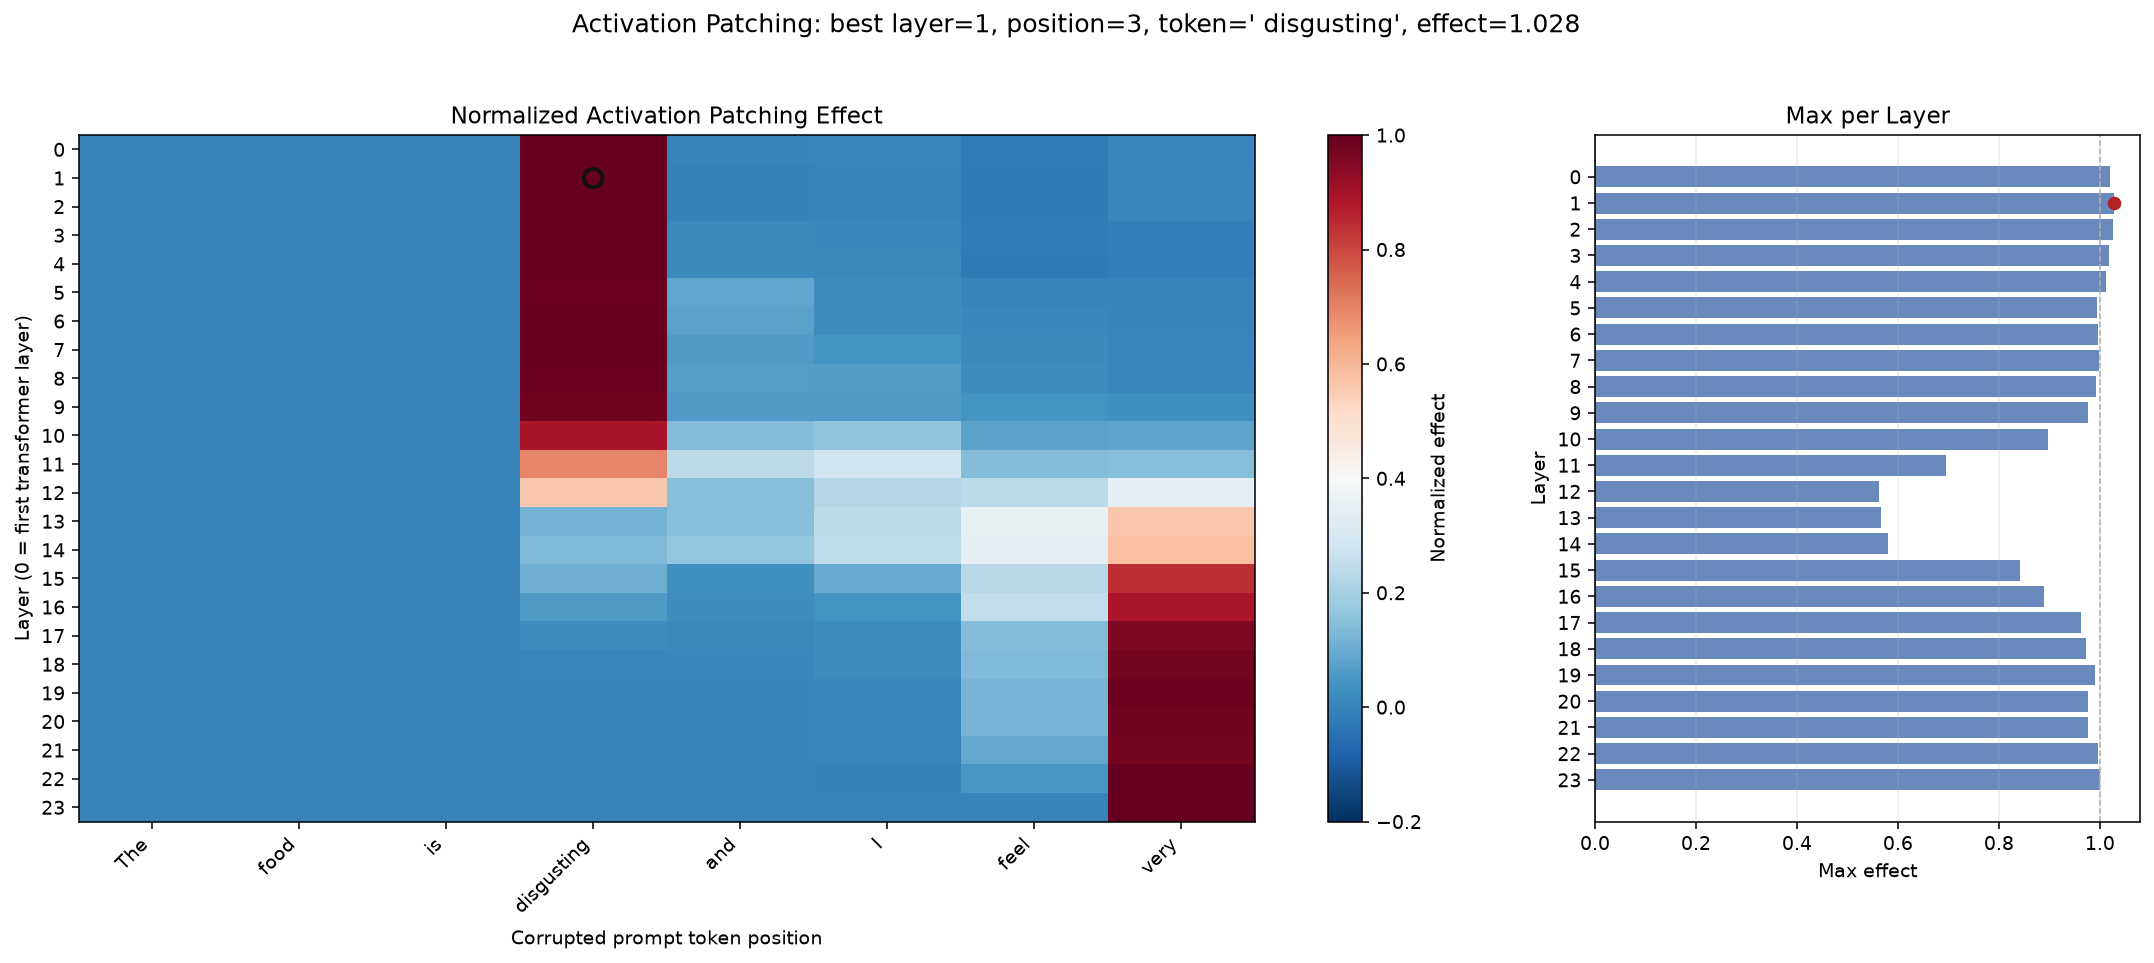

In [6]:
# Save and display the normalized patching heatmap and max-effect-per-layer panel.
# The x-axis labels show corrupted-prompt tokens: these are the positions where
# clean-prompt activations are inserted during patching.
activation_patching_plot_path = plot_activation_patching_results(
    patching_result,
    patching_state,
    filename_or_path=config.ACTIVATION_PATCHING_HEATMAP_PATH,
)
display_image(config.ACTIVATION_PATCHING_HEATMAP_PATH.name)


## 7. Top-Patching-Punkte analysieren

In [7]:
# Print the top layer/position combinations ranked by normalized patching effect.
# The table reports both the corrupted token being patched and the clean token inserted.
top_patching_points = top_activation_patching_points(
    patching_result,
    patching_state,
    top_k=50,
)


Rank   Layer   Position  Corrupted token    Clean patch token  Effect
----------------------------------------------------------------------------------
1      1       3         ' disgusting'      ' delicious'       1.028384
2      2       3         ' disgusting'      ' delicious'       1.026830
3      0       3         ' disgusting'      ' delicious'       1.019385
4      3       3         ' disgusting'      ' delicious'       1.017182
5      4       3         ' disgusting'      ' delicious'       1.012349
6      23      7         ' very'            ' very'            1.000000
7      7       3         ' disgusting'      ' delicious'       0.997904
8      6       3         ' disgusting'      ' delicious'       0.996125
9      22      7         ' very'            ' very'            0.995939
10     5       3         ' disgusting'      ' delicious'       0.993403
11     8       3         ' disgusting'      ' delicious'       0.991839
12     19      7         ' very'            ' very'    

## 8. BONUS: Head-Level Patching

Head-level patching position: position=3, corrupted_token=' disgusting', clean_patch_token=' delicious'
Head patching layer 24/24
Unchanged file: activation_patching_head_heatmap.png


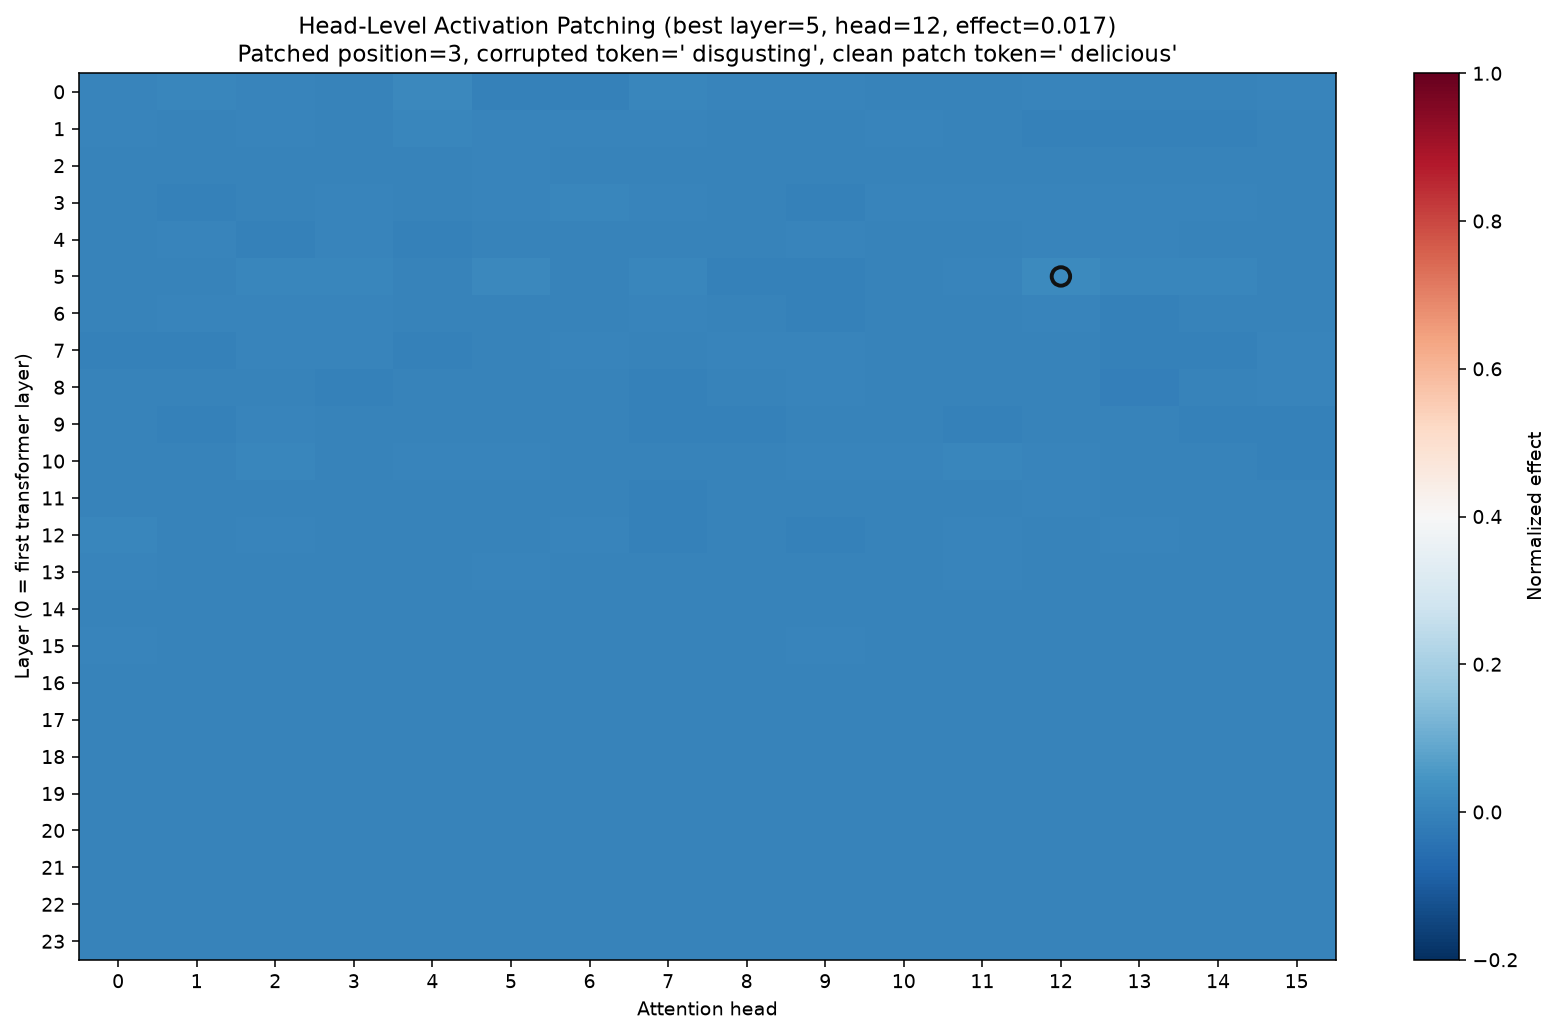

In [8]:
# Optional head-level patching: patch each attention-head slice at the most important
# token position found in the layer/position patching experiment.
# The function prints the patched position and token pair, and the same information
# is included in the heatmap title.
head_patching_result = run_head_level_patching(
    model,
    patching_state,
    patch_pos=top_patching_points[0]["position"],
    filename_or_path=config.ACTIVATION_PATCHING_HEAD_HEATMAP_PATH,
)
display_image(config.ACTIVATION_PATCHING_HEAD_HEATMAP_PATH.name)


## 9. Reflexionsfragen

### Antworten auf die Reflexionsfragen

1. Activation Patching ist kausaler als Attention-Analyse, weil es aktiv in den Modelllauf eingreift. Attention zeigt nur, wohin Information fließt; Patching testet, ob eine bestimmte Aktivierung tatsächlich zur Ausgabe beiträgt.

2. Die stärkste Schicht und Position stehen in der Top-10-Tabelle und sind in der Heatmap markiert.

3. Probing und Patching messen unterschiedliche Dinge. Probing fragt, ob Information linear dekodierbar ist. Patching fragt, ob diese Information kausal für eine konkrete Vorhersage genutzt wird. Eine Diskrepanz bedeutet, dass Information vorhanden sein kann, ohne direkt ausgaberelevant zu sein.

4. Activation Patching ist rechenintensiv, hängt stark vom gewählten Clean/Corrupted-Prompt-Paar ab und kann durch Superposition schwer interpretierbar werden. Außerdem testet ein Patch immer nur eine konkrete Intervention, nicht automatisch alle möglichen kausalen Pfade.

5. Für Head-Level-Patching patcht man nicht die ganze Schichtaktivierung, sondern nur den Aktivierungsanteil eines einzelnen Attention Heads. Dadurch kann man herausfinden, welche Heads kausal zur Wiederherstellung der korrekten Antwort beitragen.


## 10. Zussamenfassung

Die Activation-Patching-Analyse liefert erstmals kausale Evidenz dafür, welche Komponenten des Modells für die sentimentbezogene Vorhersage verantwortlich sind. Im Gegensatz zu Logit Lens und Linear Probing, die lediglich zeigen, wo Sentiment-Informationen beobachtbar oder dekodierbar sind, untersucht Activation Patching direkt, welche Repräsentationen tatsächlich zur finalen Vorhersage beitragen.

Die Ergebnisse zeigen, dass der stärkste Effekt durch das Patchen des Tokens *"disgusting"* mit der Aktivierung des entsprechenden Tokens *"delicious"* aus dem Clean Prompt erzielt wird. Die höchsten Effekte treten bereits in den frühen Schichten auf. Der stärkste Patch-Punkt befindet sich in Layer 1 an Position 3 (*"disgusting"*) mit einem normierten Effekt von 1.028. Auch die benachbarten frühen Schichten 0 bis 4 zeigen nahezu identische Effekte von etwa 1.0. Dies deutet darauf hin, dass die sentimenttragende Information unmittelbar nach der Verarbeitung des sentimentrelevanten Tokens in die Repräsentation eingebettet wird.

Die Heatmap bestätigt dieses Ergebnis deutlich. Der höchste Einfluss konzentriert sich auf die Position des sentimenttragenden Wortes (*"disgusting" → "delicious"*). Andere Tokenpositionen zeigen wesentlich geringere Effekte. Damit scheint die Polarität des Satzes primär durch die Repräsentation des eigentlichen Sentiment-Wortes bestimmt zu werden.

Interessanterweise zeigen die späten Schichten ebenfalls hohe Patching-Effekte, jedoch an den letzten Positionen des Prompts, insbesondere beim Token *"very"*. Dies deutet darauf hin, dass die früh extrahierte Sentiment-Information in den späteren Schichten weiterverarbeitet und bis zur finalen Vorhersage propagiert wird. Die mittleren Schichten weisen dagegen deutlich geringere Effekte auf, was auf eine Übergangsphase der Informationsverarbeitung hindeuten könnte.

Die Analyse auf Ebene einzelner Attention Heads zeigt ein anderes Bild. Der stärkste Head befindet sich in Layer 5, Head 12, erreicht jedoch nur einen Effekt von 0.017. Im Vergleich zu den Effekten des vollständigen Residual Streams ist dieser Beitrag sehr klein. Daraus lässt sich schließen, dass die sentimentrelevante Information nicht von einem einzelnen dominanten Attention Head getragen wird, sondern über mehrere Heads und Komponenten des Modells verteilt repräsentiert wird.

Zusammenfassend legen die Ergebnisse nahe, dass die sentimentbezogene Information bereits in den ersten Transformer-Schichten durch das Wort *"disgusting"* bzw. *"delicious"* erzeugt wird und anschließend über die verbleibenden Schichten weitertransportiert und verstärkt wird. Die starke Wirkung des Patches auf der Position des Sentiment-Wortes liefert kausale Evidenz dafür, dass genau dieses Token den entscheidenden Beitrag zur späteren Vorhersage von positiven bzw. negativen Fortsetzungen leistet. Die Ergebnisse ergänzen die vorherigen Befunde aus Logit Lens und Linear Probing: Während diese Methoden zeigen, dass Sentiment im Modell repräsentiert wird, zeigt Activation Patching, welche Repräsentationen tatsächlich ursächlich für die finale Vorhersage sind.